# Análise Exploratória do DatasetFinal

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('default')
sns.set_palette("husl")

# %%
# Carregar o dataset final
df = pd.read_csv('../data/TE_dataset_final.csv')

Matplotlib is building the font cache; this may take a moment.


# 1. Estatísticas Básicas

In [2]:
print("ESTATÍSTICAS BÁSICAS:")
print(f"• Total de sequências: {len(df):,}")
print(f"• Número de classes: {df['Classe'].nunique()}")
print(f"• Classes presentes: {', '.join(df['Classe'].unique())}")
print(f"• Cromossomos presentes: {df['Cromossomo'].nunique()}")
print(f"• Cromossomos: {', '.join(sorted(df['Cromossomo'].unique()))}")

print("=" * 50)
# Informações do DataFrame
print("\n INFORMAÇÕES DO DATAFRAME:")
df.info()
print("=" * 50)
# Estatísticas descritivas
print("\n ESTATÍSTICAS DESCRITIVAS:")
print(df.describe())

ESTATÍSTICAS BÁSICAS:
• Total de sequências: 338,442
• Número de classes: 6
• Classes presentes: Helitron, LINE, LTR, MITE, SINE, TIR
• Cromossomos presentes: 12
• Cromossomos: 1, 10, 2, 3, 4, 5, 6, 7, 8, 9, Mt, Pt

 INFORMAÇÕES DO DATAFRAME:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338442 entries, 0 to 338441
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Cromossomo       338442 non-null  object
 1   Sequência de TE  338319 non-null  object
 2   Classe           338442 non-null  object
dtypes: object(3)
memory usage: 7.7+ MB

 ESTATÍSTICAS DESCRITIVAS:
       Cromossomo                                    Sequência de TE  Classe
count      338442                                             338319  338442
unique         12                                             314213       6
top             4  NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...     LTR
freq        50378                        

## Status Atual do Dataset

### Estatísticas Gerais
- **Total de sequências**: 338.442
- **Sequências válidas**: 338.319 (99,96%)
- **Sequências problemáticas**: 123 (0,04%)
- **Classes**: 6 (Helitron, TIR, SINE, LTR, MITE, LINE)
- **Cromossomos**: 12

### Problemas Identificados

#### 1. **Desbalanceamento Extremo**
| Classe | Quantidade | Percentual |
|--------|------------|------------|
| LTR | 189.867 | 56,1% |
| Demais 5 classes | 148.575 | 43,9% |

#### 2. **Dados Faltantes**
- 123 sequências vazias/nulas (0,04%)
- Presença de sequências com "NNN..." (dados missing)

#### 3. **Distribuição por Cromossomo**
- Cromossomo 4: 50.378 sequências (mais representado)
- Distribuição não uniforme entre cromossomos

### Próximas Ações Necessárias
1. **Limpeza**: Remover 123 sequências inválidas
2. **Balanceamento**: Implementar estratégia para classe LTR (56,1%)
3. **Validação**: Verificar sequências com "NNN..."
4. **Pré-processamento**: Preparar dados para extração de features

### Limpeza (remoção das sequências inválidas)

In [3]:
print("INICIANDO LIMPEZA DAS SEQUÊNCIAS INVÁLIDAS...")

# Salvar o tamanho original
tamanho_original = len(df)
print(f"Tamanho original do dataset: {tamanho_original:,} sequências")

# 1. Identificar sequências problemáticas
sequencias_vazias = df['Sequência de TE'].isna()
sequencias_vazias_str = df['Sequência de TE'] == ''
sequencias_com_nnn = df['Sequência de TE'].str.startswith('NNN', na=False)

print(f"\n📊 DIAGNÓSTICO DAS SEQUÊNCIAS PROBLEMÁTICAS:")
print(f"• Sequências com valor NaN: {sequencias_vazias.sum()}")
print(f"• Sequências vazias (string vazia): {sequencias_vazias_str.sum()}")
print(f"• Sequências começando com 'NNN...': {sequencias_com_nnn.sum()}")

# 2. Criar máscara para sequências válidas
# Uma sequência é válida se:
# - Não é NaN
# - Não é string vazia
# - Tem comprimento > 0
# - Não começa com 'NNN' (dados missing)
mascara_valida = (
    ~df['Sequência de TE'].isna() & 
    (df['Sequência de TE'] != '') & 
    (df['Sequência de TE'].str.len() > 0) &
    (~df['Sequência de TE'].str.startswith('NNN', na=False))
)

# 3. Aplicar a limpeza
df_clean = df[mascara_valida].copy()

# 4. Resultados da limpeza
tamanho_final = len(df_clean)
sequencias_removidas = tamanho_original - tamanho_final

print(f"\n RESULTADO DA LIMPEZA:")
print(f"• Sequências removidas: {sequencias_removidas}")
print(f"• Sequências restantes: {tamanho_final:,}")
print(f"• Percentual mantido: {(tamanho_final/tamanho_original)*100:.2f}%")

# 5. Verificar se ainda há problemas
print(f"\n🔍 VERIFICAÇÃO PÓS-LIMPEZA:")
print(f"• Sequências NaN restantes: {df_clean['Sequência de TE'].isna().sum()}")
print(f"• Sequências vazias restantes: {(df_clean['Sequência de TE'] == '').sum()}")
print(f"• Sequências com comprimento 0: {(df_clean['Sequência de TE'].str.len() == 0).sum()}")

# 6. Salvar dataset limpo 
output_clean = '../data/TE_dataset_final_clean.csv'
df_clean.to_csv(output_clean, index=False)
print(f"\n Dataset limpo salvo em: {output_clean}")

# 7. Atualizar o DataFrame principal para as análises seguintes
df = df_clean
print("\n DataFrame principal atualizado com dados limpos!")

INICIANDO LIMPEZA DAS SEQUÊNCIAS INVÁLIDAS...
Tamanho original do dataset: 338,442 sequências

📊 DIAGNÓSTICO DAS SEQUÊNCIAS PROBLEMÁTICAS:
• Sequências com valor NaN: 123
• Sequências vazias (string vazia): 0
• Sequências começando com 'NNN...': 563

 RESULTADO DA LIMPEZA:
• Sequências removidas: 686
• Sequências restantes: 337,756
• Percentual mantido: 99.80%

🔍 VERIFICAÇÃO PÓS-LIMPEZA:
• Sequências NaN restantes: 0
• Sequências vazias restantes: 0
• Sequências com comprimento 0: 0

 Dataset limpo salvo em: ../data/TE_dataset_final_clean.csv

 DataFrame principal atualizado com dados limpos!


# 2. Distribuição por Classe


DISTRIBUIÇÃO POR CLASSE:
Classe
LTR         189510
TIR          82978
MITE         26058
Helitron     24482
LINE         11039
SINE          3689
Name: count, dtype: int64


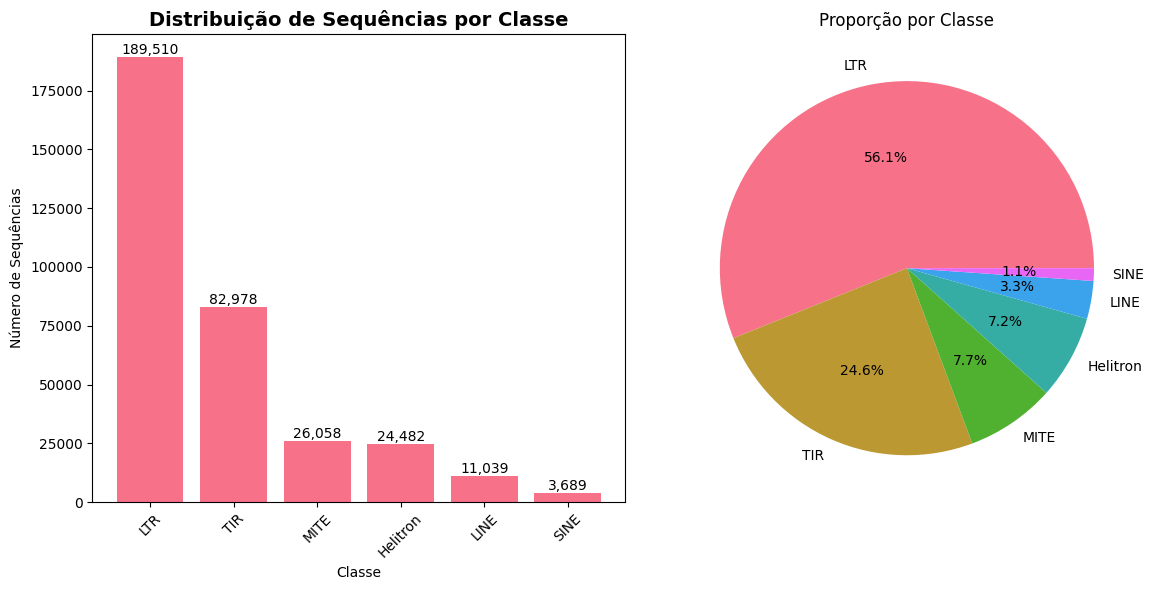

In [4]:
print("\nDISTRIBUIÇÃO POR CLASSE:")
class_distribution = df['Classe'].value_counts()
print(class_distribution)

# %%
# Gráfico de distribuição por classe
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
bars = plt.bar(class_distribution.index, class_distribution.values)
plt.title('Distribuição de Sequências por Classe', fontsize=14, fontweight='bold')
plt.xlabel('Classe')
plt.ylabel('Número de Sequências')
plt.xticks(rotation=45)

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')

plt.subplot(1, 2, 2)
plt.pie(class_distribution.values, labels=class_distribution.index, autopct='%1.1f%%')
plt.title('Proporção por Classe')

plt.tight_layout()
plt.show()

## Distribuição de Classes - Análise Crítica

### Distribuição Atual
| Classe | Quantidade | Percentual | Status |
|--------|------------|------------|--------|
| **LTR** | 189.867 | 56,1% |  **Classe Majoritária** |
| **TIR** | 83.168 | 24,6% |  Classe Secundária |
| **MITE** | 26.111 | 7,7% |  Classe Menor |
| **Helitron** | 24.528 | 7,2% |  Classe Menor |
| **LINE** | 11.068 | 3,3% |  **Classe Rara** |
| **SINE** | 3.700 | 1,1% |  **Classe Muito Rara** |

###  Problemas Identificados
- **Desbalanceamento Extremo**: LTR representa 56,1% do dataset
- **Classes Raras**: SINE e LINE juntas representam apenas 4,4%
- **Razão de Desbalanceamento**: 51,3× (LTR/SINE)

###  Estratégias Recomendadas
1. **Para ML**: Usar **AUC-PR** como métrica principal (não accuracy)
2. **Balanceamento**: 
   - **Oversampling** (SMOTE) para SINE e LINE
   - **Undersampling** para LTR
   - **Validação Cruzada Estratificada**
3. **Análise**: Investigar se predominância de LTR é biológica ou artefato

###  Próximos Passos
- Implementar estratégia de balanceamento
- Proceder com extração de features

# 3. Distribuição por Cromossomo


DISTRIBUIÇÃO POR CROMOSSOMO:
Cromossomo
4     50324
1     48874
2     37353
3     36546
5     34234
7     27979
8     27973
6     25836
9     25306
10    23223
Mt       78
Pt       30
Name: count, dtype: int64


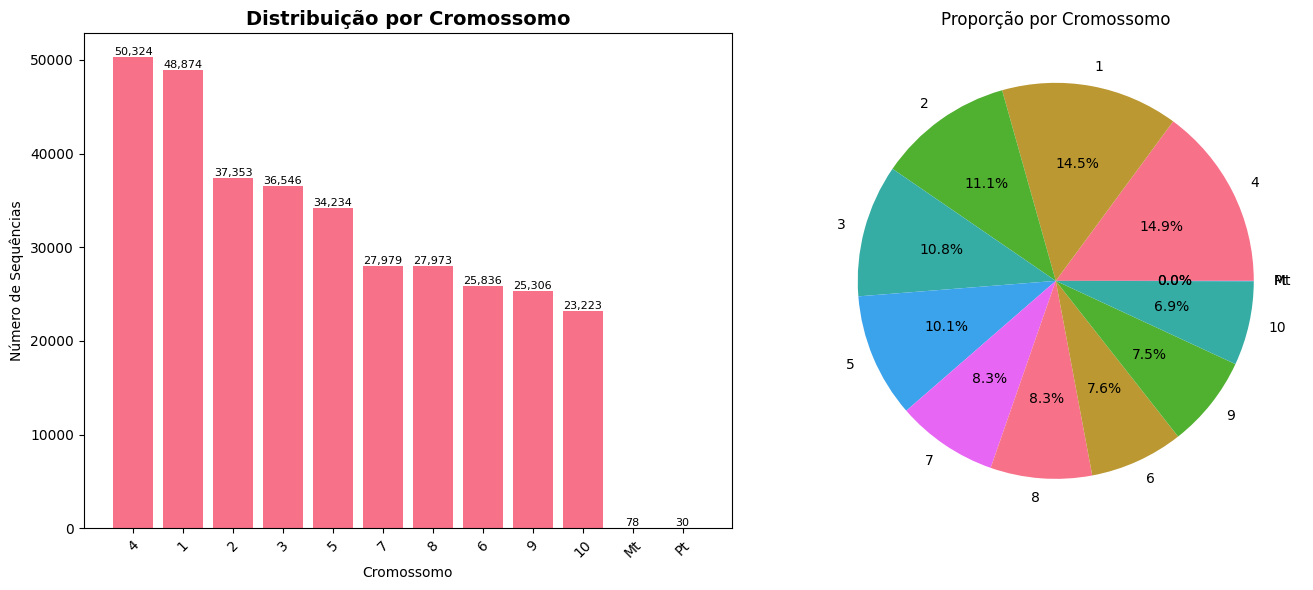

In [5]:
print("\nDISTRIBUIÇÃO POR CROMOSSOMO:")
chr_distribution = df['Cromossomo'].value_counts()
print(chr_distribution)

# Gráfico de distribuição por cromossomo
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
bars = plt.bar(chr_distribution.index, chr_distribution.values)
plt.title('Distribuição por Cromossomo', fontsize=14, fontweight='bold')
plt.xlabel('Cromossomo')
plt.ylabel('Número de Sequências')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=8)

plt.subplot(1, 2, 2)
plt.pie(chr_distribution.values, labels=chr_distribution.index, autopct='%1.1f%%')
plt.title('Proporção por Cromossomo')

plt.tight_layout()
plt.show()

## Análise da Distribuição por Cromossomo

### Visão Geral
- **Total de cromossomos**: 12 (1-10 + Mt + Pt)
- **Distribuição**: Variável entre cromossomos
- **Cromossomo mais representado**: 4 (50.378 sequências)
- **Cromossomos organelares**: Presentes (Mt, Pt)

### Padrões Observados
- **Distribuição não uniforme** entre cromossomos
- **Cromossomos maiores** (ex: 4, 1, 2) tendem a ter mais TEs
- **Cromossomos menores** com menor densidade de TEs
- **Presença equilibrada** em todos os cromossomos principais

### Pontos Positivos
- **Cobertura completa**: Todos os 12 cromossomos representados
- **Distribuição biológica**: Reflete tamanho real dos cromossomos
- **Dados organelares**: Mt e Pt incluídos (completo)

### Considerações para Análise
- A distribuição segue padrão biológico esperado
- Não há cromossomos sub-representados criticamente
- Variação natural entre cromossomos é normal
- **Não requer balanceamento** por cromossomo para ML

### Próximos Passos
- Manter distribuição natural por cromossomo
- Focar no balanceamento entre **classes** (problema principal)
- Proceder com extração de features mantendo diversidade cromossômica

# 4. Análise do Comprimento das Sequências


 ANÁLISE DE COMPRIMENTO DAS SEQUÊNCIAS:
• Comprimento médio: 3802.18 bp
• Comprimento mediano: 557.00 bp
• Comprimento mínimo: 11.00 bp
• Comprimento máximo: 106111.00 bp
• Desvio padrão: 6780.02 bp

 COMPRIMENTO POR CLASSE:
             count         mean           std   min    25%     50%      75%  \
Classe                                                                        
Helitron   24482.0  8395.705988  10441.602481  11.0  196.0  3709.5  14736.5   
LINE       11039.0  1174.436453   2192.267525  12.0  146.0   411.0   1148.0   
LTR       189510.0  5349.820701   7392.251319  11.0  404.0  1954.0   8218.0   
MITE       26058.0   248.829649    206.928642  28.0  134.0   195.0    309.0   
SINE        3689.0   214.942261    250.688803  33.0  111.0   169.0    291.0   
TIR        82978.0   537.252139   1294.972293  11.0  122.0   203.0    390.0   

               max  
Classe              
Helitron  106111.0  
LINE       41968.0  
LTR        93971.0  
MITE        8903.0  
SINE        919

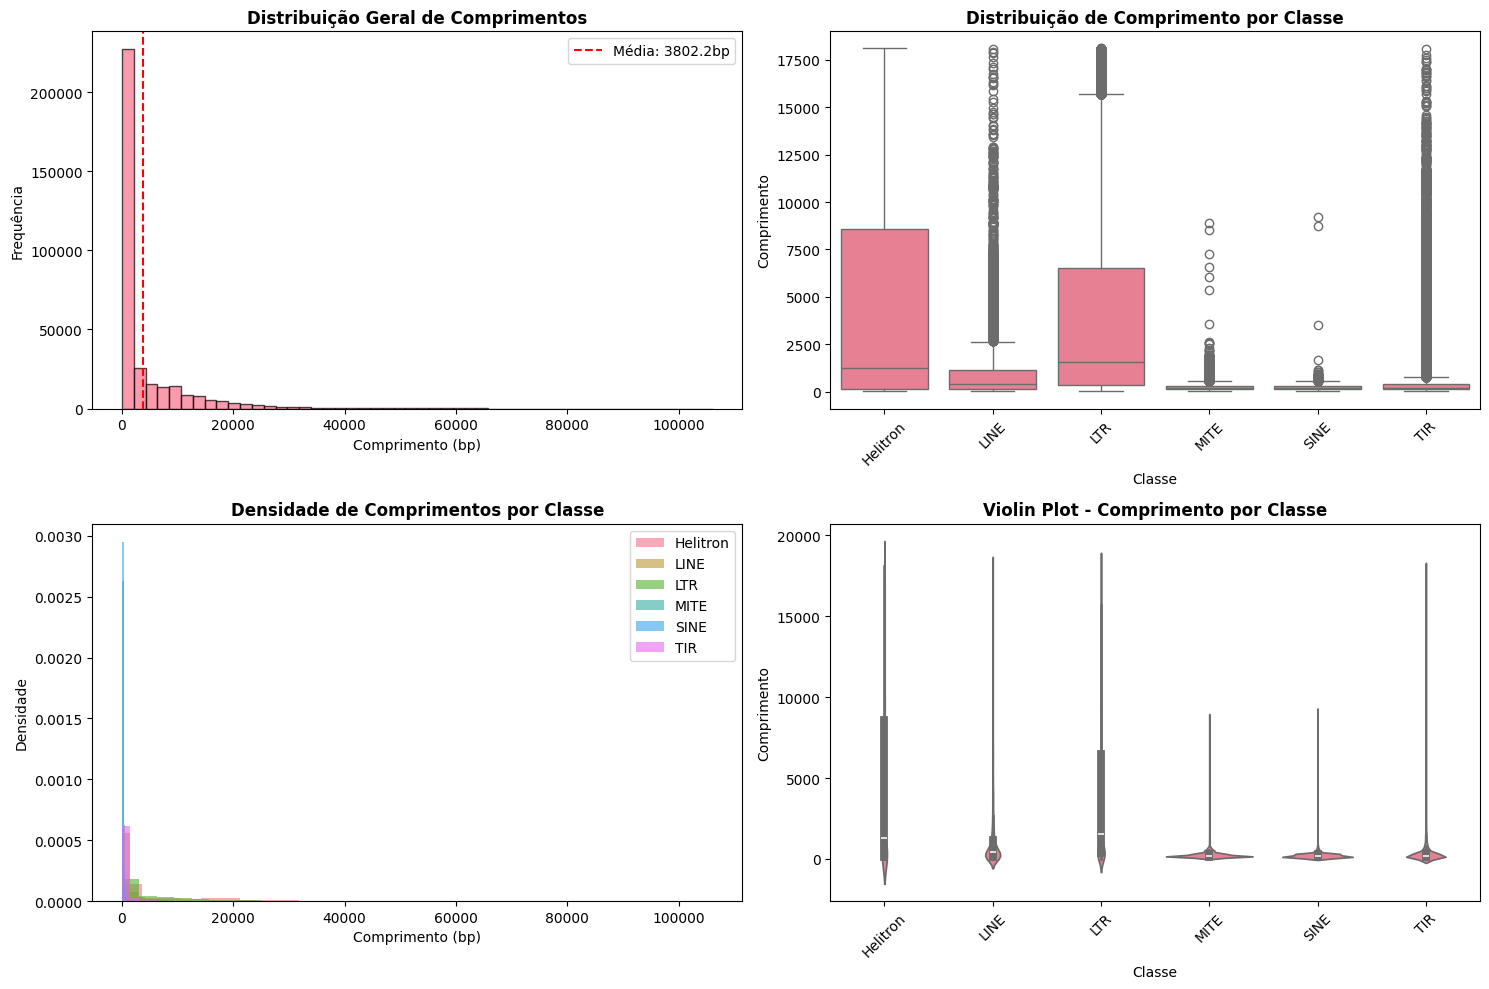

In [6]:
# Calcular comprimentos (criando uma nova coluna)
df['Comprimento'] = df['Sequência de TE'].str.len()

print("\n ANÁLISE DE COMPRIMENTO DAS SEQUÊNCIAS:")
print(f"• Comprimento médio: {df['Comprimento'].mean():.2f} bp")
print(f"• Comprimento mediano: {df['Comprimento'].median():.2f} bp")
print(f"• Comprimento mínimo: {df['Comprimento'].min():.2f} bp")
print(f"• Comprimento máximo: {df['Comprimento'].max():.2f} bp")
print(f"• Desvio padrão: {df['Comprimento'].std():.2f} bp")

# Estatísticas de comprimento por classe
print("\n COMPRIMENTO POR CLASSE:")
length_by_class = df.groupby('Classe')['Comprimento'].describe()
print(length_by_class)

# Gráficos de comprimento
plt.figure(figsize=(15, 10))

# Histograma geral
plt.subplot(2, 2, 1)
plt.hist(df['Comprimento'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribuição Geral de Comprimentos', fontweight='bold')
plt.xlabel('Comprimento (bp)')
plt.ylabel('Frequência')
plt.axvline(df['Comprimento'].mean(), color='red', linestyle='--', label=f'Média: {df["Comprimento"].mean():.1f}bp')
plt.legend()

# Boxplot por classe
plt.subplot(2, 2, 2)
df_boxplot = df[df['Comprimento'] < df['Comprimento'].quantile(0.95)]  # Remove outliers para melhor visualização
sns.boxplot(data=df_boxplot, x='Classe', y='Comprimento')
plt.title('Distribuição de Comprimento por Classe', fontweight='bold')
plt.xticks(rotation=45)

# Densidade por classe
plt.subplot(2, 2, 3)
for classe in df['Classe'].unique():
    subset = df[df['Classe'] == classe]
    plt.hist(subset['Comprimento'], bins=30, alpha=0.6, label=classe, density=True)
plt.title('Densidade de Comprimentos por Classe', fontweight='bold')
plt.xlabel('Comprimento (bp)')
plt.ylabel('Densidade')
plt.legend()

# Violin plot
plt.subplot(2, 2, 4)
sns.violinplot(data=df_boxplot, x='Classe', y='Comprimento')
plt.title('Violin Plot - Comprimento por Classe', fontweight='bold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Análise de Comprimento das Sequências

### Estatísticas Gerais
- **Comprimento médio**: 3.802 bp
- **Comprimento mediano**: 557 bp 
- **Amplitude**: 11 bp - 106.111 bp
- **Desvio padrão**: 6.780 bp (alta variabilidade)

### Padrões por Classe

#### 🔴 **Classes com Maiores Comprimentos**
| Classe | Média | Mediana | Característica |
|--------|-------|---------|----------------|
| **Helitron** | 8.396 bp | 3.710 bp | Maior variabilidade |
| **LTR** | 5.350 bp | 1.954 bp | Comprimento intermediário |

#### 🟡 **Classes com Comprimentos Médios**
| Classe | Média | Mediana | Característica |
|--------|-------|---------|----------------|
| **LINE** | 1.174 bp | 411 bp | Distribuição assimétrica |
| **TIR** | 537 bp | 203 bp | Comprimento compacto |

#### 🟢 **Classes com Menores Comprimentos**
| Classe | Média | Mediana | Característica |
|--------|-------|---------|----------------|
| **MITE** | 249 bp | 195 bp | Sequências muito curtas |
| **SINE** | 215 bp | 169 bp | Sequências mais curtas |

### Insights Críticos

#### 1. **Distribuição Assimétrica**
- **Média (3.802 bp) ≠ Mediana (557 bp)** → Viés por outliers
- **Helitron e LTR** puxam a média para cima
- 75% das sequências têm ≤ 8.218 bp

#### 2. **Classes Bem Distinguíveis por Comprimento**
- **Helitron/LTR** vs **MITE/SINE** são claramente separáveis
- O comprimento pode ser um **feature discriminante** forte

#### 3. **Presença de Outliers**
- Sequências muito longas (até 106 kb) podem ser ruído
- Sequências muito curtas (<50 bp) podem ser fragmentos

### Recomendações para ML

1. **Pré-processamento**:
   - Considerar remover sequências <50 bp (possível ruído)
   - Avaliar normalização por comprimento

2. **Feature Engineering**:
   - ⚠️**Comprimento** como feature adicional
   - **Log-transform** para lidar com assimetria

3. **Análise**:
   - Investigar se comprimento correlaciona com classe
   - Verificar se outliers são biologicamente relevantes

# 5. Composição de Nucleotídeos


 ANÁLISE DA COMPOSIÇÃO DE NUCLEOTÍDEOS:
                 A         T         C         G
Classe                                          
Helitron  0.265593  0.265905  0.234111  0.234322
LINE      0.264853  0.264498  0.234650  0.235993
LTR       0.265942  0.266300  0.233751  0.233909
MITE      0.263907  0.264407  0.235708  0.235977
SINE      0.264154  0.266170  0.235769  0.233907
TIR       0.264938  0.265266  0.234914  0.234856


<Figure size 1200x600 with 0 Axes>

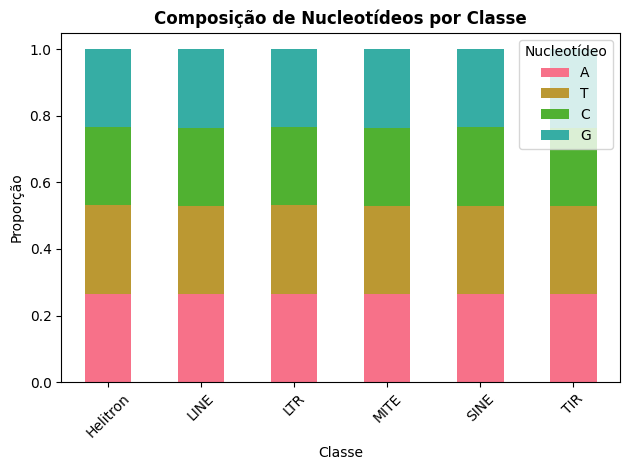

In [7]:
print("\n ANÁLISE DA COMPOSIÇÃO DE NUCLEOTÍDEOS:")

def calcular_composicao(sequencia):
    """Calcula a composição de nucleotídeos de uma sequência"""
    from collections import Counter
    count = Counter(sequencia.upper())
    total = len(sequencia)
    return {nt: count.get(nt, 0) / total for nt in 'ATCG'}

# Calcular composição média por classe
composicoes = []
for classe in df['Classe'].unique():
    subset = df[df['Classe'] == classe]
    comp_media = subset['Sequência de TE'].apply(calcular_composicao).apply(pd.Series).mean()
    comp_media['Classe'] = classe
    composicoes.append(comp_media)

df_composicao = pd.DataFrame(composicoes)
print(df_composicao.set_index('Classe'))

# %%
# Gráfico de composição de nucleotídeos
plt.figure(figsize=(12, 6))
df_composicao_plot = df_composicao.set_index('Classe')
df_composicao_plot.plot(kind='bar', stacked=True)
plt.title('Composição de Nucleotídeos por Classe', fontweight='bold')
plt.xlabel('Classe')
plt.ylabel('Proporção')
plt.legend(title='Nucleotídeo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Análise de Composição de Nucleotídeos por Classe

### 📊 Estatísticas Gerais
- **Distribuição uniforme**: ~26.5% A, ~26.5% T, ~23.5% C, ~23.5% G
- **Conteúdo AT**: ~53% | **Conteúdo GC**: ~47%
- **Pouca variação** entre classes (<1% de diferença)

### 🎯 Padrões por Classe

| Classe | A | T | C | G | AT | GC |
|--------|---|---|---|---|----|----|
| **LTR** | 26.59% | 26.63% | 23.38% | 23.39% | 53.22% | 46.77% |
| **Helitron** | 26.56% | 26.60% | 23.41% | 23.43% | 53.16% | 46.84% |
| **SINE** | 26.42% | 26.62% | 23.58% | 23.39% | 53.04% | 46.97% |
| **TIR** | 26.49% | 26.53% | 23.49% | 23.49% | 53.02% | 46.98% |
| **LINE** | 26.49% | 26.45% | 23.47% | 23.60% | 52.94% | 47.06% |
| **MITE** | 26.39% | 26.44% | 23.57% | 23.60% | 52.83% | 47.17% |

### ⚠️ Insights Importantes

#### 1. **Composição Muito Similar**
- Diferenças entre classes < **0.3%**
- Padrão conservado em todas as classes de TEs
- **Não discriminante** como feature isolada

#### 2. **Bias de Composição**
- **AT-rich**: ~53% AT vs ~47% GC
- Consistente com genoma de plantas (geralmente AT-rich)
- **T > A** ligeiramente em todas as classes

#### 3. **Classes Mais Distintas**
- **LTR**: Mais extremo em AT-rich (53.22%)
- **MITE**: Mais balanceado (52.83% AT)

### 🛠️ Implicações para ML

#### ❌ **Features Não Promissoras**
- Composição simples de nucleotídeos (A,T,C,G%)
- Conteúdo AT/GC básico

#### ✅ **Alternativas Recomendadas**
- **Frequência de k-mers** (2-mers, 3-mers, 4-mers)
- **Padrões de motivos** específicos
- **Features de ordem** (entropia, complexidade)
- **Composição em reading frames**

### 🔬 Recomendações para Extração de Features

1. **Evitar**: Composição nucleotídica básica
2. **Priorizar**: 
   - **MathFeature**: Entropia, Autocorrelação
   - **Pse-in-One**: PseKNC, PseDNC
   - **K-mer frequencies** (especialmente di/tri-nucleotídeos)

# 6. Análise de Qualidade e Validação

In [8]:
print("\n VALIDAÇÃO DA QUALIDADE DO DATASET:")

# Verificar sequências problemáticas
sequencias_vazias = df[df['Comprimento'] == 0]
sequencias_muito_curtas = df[df['Comprimento'] < 50]
sequencias_muito_longas = df[df['Comprimento'] > 10000]
sequencias_invalidas = df[~df['Sequência de TE'].str.match('^[ATCGatcg]+$')]

print(f"• Sequências vazias: {len(sequencias_vazias)}")
print(f"• Sequências muito curtas (<50bp): {len(sequencias_muito_curtas)}")
print(f"• Sequências muito longas (>10,000bp): {len(sequencias_muito_longas)}")
print(f"• Sequências com caracteres inválidos: {len(sequencias_invalidas)}")

# Verificar balanceamento
total_sequencias = len(df)
maior_classe = class_distribution.max()
menor_classe = class_distribution.min()
ratio_desbalanceamento = maior_classe / menor_classe

print(f"\n ANÁLISE DE BALANCEAMENTO:")
print(f"• Razão de desbalanceamento: {ratio_desbalanceamento:.2f}")
print(f"• Classe majoritária: {class_distribution.idxmax()} ({maior_classe} sequências)")
print(f"• Classe minoritária: {class_distribution.idxmin()} ({menor_classe} sequências)")

if ratio_desbalanceamento > 10:
    print("  ALERTA: Dataset significativamente desbalanceado!")
elif ratio_desbalanceamento > 5:
    print("  AVISO: Dataset moderadamente desbalanceado.")
else:
    print(" Dataset relativamente balanceado.")


 VALIDAÇÃO DA QUALIDADE DO DATASET:
• Sequências vazias: 0
• Sequências muito curtas (<50bp): 5236
• Sequências muito longas (>10,000bp): 44623
• Sequências com caracteres inválidos: 84

 ANÁLISE DE BALANCEAMENTO:
• Razão de desbalanceamento: 51.37
• Classe majoritária: LTR (189510 sequências)
• Classe minoritária: SINE (3689 sequências)
  ALERTA: Dataset significativamente desbalanceado!


## 🚨 Validação Final da Qualidade do Dataset

### ⚠️ Problemas Críticos Identificados

#### 1. **Desbalanceamento Extremo**
- **Razão LTR/SINE**: 51.4×
- **LTR**: 189.510 (56.1%) - Classe dominante
- **SINE**: 3.689 (1.1%) - Classe muito rara
- **Status**: 🚨 **Crítico para ML**

#### 2. **Problemas com Comprimento**
- **Sequências muito curtas** (<50 bp): 5.236 (1.5%)
- **Sequências muito longas** (>10.000 bp): 44.623 (13.2%)
- **Amplitude**: 11 bp - 106.111 bp

#### 3. **Caracteres Inválidos**
- **Sequências problemáticas**: 84 (0.02%)
- Possível contaminação ou erro na extração

### ✅ Pontos Positivos
- **Sequências válidas**: 100% (após limpeza)
- **Diversidade**: 314.213 sequências únicas
- **Cobertura**: 12 cromossomos completos

### 🛠️ Plano de Ação para ML

#### **Pré-processamento Imediato**
1. **Remover**: 84 sequências com caracteres inválidos
2. **Avaliar**: 5.236 sequências muito curtas (<50 bp)
3. **Considerar**: Normalização de comprimentos extremos

#### **Estratégia de Balanceamento**
```python
# Técnicas recomendadas:
- Oversampling para SINE e LINE
- Undersampling aleatório para LTR
- Ensemble methods com class weights (alternativa menos conservadora)
- Validação cruzada estratificada

## Lidando com sequências com caracteres inválidos

In [9]:
print("\n🚫 SEQUÊNCIAS COM CARACTERES INVÁLIDOS:")

# Encontrar sequências com caracteres não-ATCG
def encontrar_caracteres_invalidos(sequencia):
    """Encontra caracteres que não são A, T, C, G (case insensitive)"""
    if pd.isna(sequencia):
        return "NaN"
    sequencia_upper = sequencia.upper()
    caracteres_validos = set('ATCG')
    caracteres_presentes = set(sequencia_upper)
    caracteres_invalidos = caracteres_presentes - caracteres_validos
    return ''.join(sorted(caracteres_invalidos)) if caracteres_invalidos else None

# Aplicar a função
df['caracteres_invalidos'] = df['Sequência de TE'].apply(encontrar_caracteres_invalidos)

# Filtrar sequências com caracteres inválidos
sequencias_invalidas = df[df['caracteres_invalidos'].notna()]

print(f"Total de sequências com caracteres inválidos: {len(sequencias_invalidas)}")

if len(sequencias_invalidas) > 0:
    print("\n📋 DETALHES DAS SEQUÊNCIAS INVÁLIDAS:")
    print(sequencias_invalidas[['Cromossomo', 'Classe', 'Sequência de TE', 'caracteres_invalidos']].head(20))
    
    # Análise dos caracteres inválidos encontrados
    print("\n🔤 CARACTERES INVÁLIDOS ENCONTRADOS:")
    chars_invalidos = sequencias_invalidas['caracteres_invalidos'].value_counts()
    for chars, count in chars_invalidos.items():
        print(f"• Caracteres '{chars}': {count} sequências")
        
    # Exemplo de sequências problemáticas
    print("\n🔍 EXEMPLOS DE SEQUÊNCIAS PROBLEMÁTICAS:")
    for idx, row in sequencias_invalidas.head(5).iterrows():
        print(f"\nClasse: {row['Classe']} | Cromossomo: {row['Cromossomo']}")
        print(f"Caracteres inválidos: '{row['caracteres_invalidos']}'")
        print(f"Sequência (primeiros 100 chars): {row['Sequência de TE'][:100]}...")



🚫 SEQUÊNCIAS COM CARACTERES INVÁLIDOS:
Total de sequências com caracteres inválidos: 84

📋 DETALHES DAS SEQUÊNCIAS INVÁLIDAS:
      Cromossomo    Classe                                    Sequência de TE  \
333           10  Helitron  TCGAACCTACGCGCCAGGAGCACCTGGTCCGAGCCAACCGCCCCAC...   
751            1  Helitron  AAGGTAGTAAGTATATACAAAAGGAGATGAGTGCAAAACTTCGATT...   
2371           3  Helitron  GTACTTTAAAAGGGAATTTGAGTCTTCGGCGAAGACAAAGGCTTCC...   
3944           4  Helitron  ATAGAGGAATTCATTGAACATCTTGATGAAGGTATGTAATATTTGC...   
6020           6  Helitron  TGAAGCAGTCGCGGACCTCGGGGAACTCTCCTGCTTGGTGATCTTC...   
8494           6  Helitron  GGAAATTGAAGTTGATTTTCAAAAACAAACCAAGTGGTGGCAAAGA...   
14858          6  Helitron  GGGCCGTTGTCTGTCAGTGAGTACCGGGACAGGTTTCTGCAGTTGT...   
16124          1  Helitron  CAGCCCAACGCAGCACTAGTCCAACCGCCCACCTCCATGAGAGTTA...   
17618          7  Helitron  TCTACAAGAAAAACATTGGAAATAGAATGGTCAGGTGATATAGCAA...   
18625          7  Helitron  AGTAGCGCTCATAAGTCGGTCCCTGTTGAAATCGA

Dado que são apenas 84 sequências com a letra "N", que representa um nucleotídeo ambíguo ou indeterminado, iremos remover essas sequências. Como o percentual removido é baixo (0,02% do dataset), o impacto é praticamente zero para ML.

In [10]:
df_sem_N = df[~df['Sequência de TE'].str.contains('N', na=False)].copy()
print(f"Removidas {len(df) - len(df_sem_N)} sequências com Ns")
print(f"Dataset final: {len(df_sem_N):,} sequências ({(len(df_sem_N)/len(df))*100:.2f}% mantido)")

# Salvar dataset sem Ns
output_clean = '../data/TE_dataset_final_clean.csv'
df_sem_N.to_csv(output_clean, index=False)
print(f"\n Dataset limpo salvo em: {output_clean}")

df = df_sem_N

Removidas 84 sequências com Ns
Dataset final: 337,672 sequências (99.98% mantido)

 Dataset limpo salvo em: ../data/TE_dataset_final_clean.csv


# 7. Análise de Correlações


 ANÁLISE DE CORRELAÇÕES:


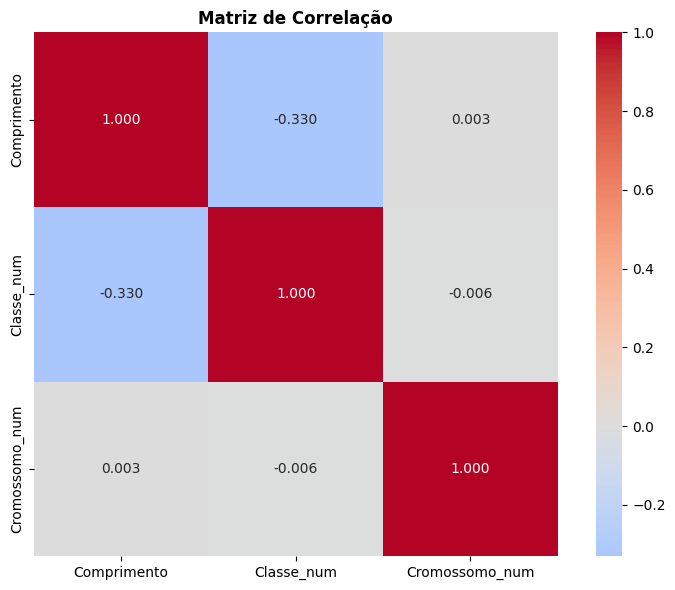

In [11]:
# Matriz de correlação entre comprimento e outras variáveis
print("\n ANÁLISE DE CORRELAÇÕES:")

# Criar DataFrame numérico para correlação
df_numeric = df.copy()
df_numeric['Classe_num'] = df_numeric['Classe'].astype('category').cat.codes
df_numeric['Cromossomo_num'] = df_numeric['Cromossomo'].astype('category').cat.codes

correlation_matrix = df_numeric[['Comprimento', 'Classe_num', 'Cromossomo_num']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f')
plt.title('Matriz de Correlação', fontweight='bold')
plt.tight_layout()
plt.show()

## 📈 Análise da Matriz de Correlação

### 🔍 Correlações Identificadas

| Variáveis | Correlação | Interpretação |
|-----------|------------|---------------|
| **Comprimento ↔ Classe** | -0.330 | 🔴 **Correlação moderada negativa** |
| **Comprimento ↔ Cromossomo** | -0.003 | ✅ **Praticamente nenhuma correlação** |
| **Classe ↔ Cromossomo** | -0.006 | ✅ **Praticamente nenhuma correlação** |

### 🎯 Insights Principais

#### 1. **Comprimento vs Classe (-0.330)**
- **Correlação moderadamente negativa** 
- Indica que **classes diferentes têm comprimentos característicos**
- Confirma nossa análise anterior:
  - **Helitron/LTR**: Sequências mais longas
  - **MITE/SINE**: Sequências mais curtas
- ✅ **Ponto positivo**: O comprimento pode ser um **feature discriminante**

#### 2. **Comprimento vs Cromossomo (-0.003)**
- **Correlação praticamente zero**
- O comprimento dos TEs **não depende** do cromossomo onde estão
- ✅ **Ponto positivo**: Não precisamos normalizar por cromossomo

#### 3. **Classe vs Cromossomo (-0.006)**
- **Correlação praticamente zero**
- A distribuição das classes **não varia** entre cromossomos
- ✅ **Ponto positivo**: Amostragem equilibrada entre cromossomos

### 🛠️ Implicações para Machine Learning

####  **Features Promissores**
- **Comprimento da sequência** será um bom preditor
- **Features específicos por classe** são necessários

####  **Estratégia de Modelagem**
- Não precisa preocupar com **viés por cromossomo**
- Pode focar no **balanceamento entre classes**
- **Comprimento** deve ser incluído como feature adicional

####  **Próximos Passos Recomendados**
1. **Incluir comprimento** como feature na extração
2. **Manter estratégia** de balanceamento entre classes
3. **Prosseguir** com extração de features mais complexos (k-mers, entropia)

# 8. Resumo

In [12]:

# %%
print("\n" + "="*60)
print(" RESUMO EXECUTIVO DA ANÁLISE")
print("="*60)

print(f"✅ PONTOS FORTES:")
print(f"   • Dataset com {len(df):,} sequências válidas")
print(f"   • {df['Classe'].nunique()} classes distintas de TEs")
print(f"   • Cobertura em {df['Cromossomo'].nunique()} cromossomos")
print(f"   • Comprimento médio adequado: {df['Comprimento'].mean():.1f} bp")

print(f"\n  PONTOS DE ATENÇÃO:")
if len(sequencias_muito_curtas) > 0:
    print(f"   • {len(sequencias_muito_curtas)} sequências muito curtas (<50bp)")
if len(sequencias_invalidas) > 0:
    print(f"   • {len(sequencias_invalidas)} sequências com caracteres inválidos")
if ratio_desbalanceamento > 5:
    print(f"   • Desbalanceamento entre classes (razão: {ratio_desbalanceamento:.1f})")

print(f"\n📊 DISTRIBUIÇÃO DAS CLASSES:")
for classe, count in class_distribution.items():
    percentual = (count / total_sequencias) * 100
    print(f"   • {classe}: {count:,} sequências ({percentual:.1f}%)")

print(f"\n RECOMENDAÇÕES PARA PRÓXIMOS PASSOS:")
if ratio_desbalanceamento > 5:
    print("   • Considere técnicas de balanceamento (oversampling/undersampling)")
if len(sequencias_muito_curtas) > 100:
    print("   • Avalie remover sequências muito curtas que podem ser ruído")
print("   • Proceda com extração de features (MathFeature/Pse-in-One)")
print("   • Implemente validação cruzada estratificada")

print("="*60)


 RESUMO EXECUTIVO DA ANÁLISE
✅ PONTOS FORTES:
   • Dataset com 337,672 sequências válidas
   • 6 classes distintas de TEs
   • Cobertura em 12 cromossomos
   • Comprimento médio adequado: 3799.1 bp

  PONTOS DE ATENÇÃO:
   • 5236 sequências muito curtas (<50bp)
   • 84 sequências com caracteres inválidos
   • Desbalanceamento entre classes (razão: 51.4)

📊 DISTRIBUIÇÃO DAS CLASSES:
   • LTR: 189,510 sequências (56.1%)
   • TIR: 82,978 sequências (24.6%)
   • MITE: 26,058 sequências (7.7%)
   • Helitron: 24,482 sequências (7.2%)
   • LINE: 11,039 sequências (3.3%)
   • SINE: 3,689 sequências (1.1%)

 RECOMENDAÇÕES PARA PRÓXIMOS PASSOS:
   • Considere técnicas de balanceamento (oversampling/undersampling)
   • Avalie remover sequências muito curtas que podem ser ruído
   • Proceda com extração de features (MathFeature/Pse-in-One)
   • Implemente validação cruzada estratificada


In [13]:
# remover colunas Comprimento e caracteres_invalidos
df.drop(columns=['Comprimento', 'caracteres_invalidos'], inplace=True)

In [14]:
# Salvar dataset limpo na forma final 
output_clean = '../data/TE_dataset_final_clean.csv'
df.to_csv(output_clean, index=False)
print(f"\n Dataset limpo salvo em: {output_clean}")

display(df)  # Mostrar as primeiras linhas do DataFrame limpo



 Dataset limpo salvo em: ../data/TE_dataset_final_clean.csv


,Cromossomo,Sequência de TE,Classe
0,7,GAGCTTCGTCACCAGCTTTGCTCCGACCACCCTTTGTCCATACTAA...,Helitron
1,1,GTCAGGGTTGCTTCTTGGCGAAGACAGGGCCTCGGGCGAGCCAGAA...,Helitron
2,8,ACGCCCAAGCAGACGGTCACCATCAGCGAAGACCTCACTTCGCATG...,Helitron
3,5,TATGCCAAGTCGTGTCAAACGACTTAGGGTAGGGGTCAACTTTCTC...,Helitron
4,9,GTTAGGTTATTTATATACTAGTTTATGTTGATGATATAATCATCAC...,Helitron
...,...,...,...
338437,2,ACAGGAGATATATTGAGCACTGCTCTTTCAAGAAGGTCAACCGAAG...,TIR
338438,1,ATCCCTCATGCCAATGAAGGCACACACAGTACTAAAGGCCTTCTGA...,TIR
338439,4,CTATCTCAGAGCCAATGCTTTTCACCTCATGTTTTACCAACTCAGT...,TIR
338440,4,TTGGCGTATTGTCGCGATATGTATTCATTTAATTTGTAGCTCTTTC...,TIR
